# 类别不均衡与分析三件套教学 Notebook

本 Notebook 对应第 15 章内容，演示 **类别不均衡的武器**（加权 CE / Focal Loss）与 **论文级分析三件套**（t-SNE / Grad-CAM / 空间分桶）。

## 本 Notebook 做什么

1. 可视化 Indian Pines 的类别分布（不均衡问题）
2. 用三种损失函数训练 2D CNN（CE / 加权 CE / Focal）
3. 对比逐类召回率——稀有类的改善一目了然
4. t-SNE 特征可视化——嵌入空间的类分离度
5. Grad-CAM——模型在看 patch 的哪个位置
6. 空间分桶误差——边界 vs 内部的精度差异

In [1]:
import json, random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cpu")

class_names = [
    "Alfalfa", "Corn-notill", "Corn-mintill", "Corn",
    "Grass-pasture", "Grass-trees", "Grass-pasture-mowed", "Hay-windrowed",
    "Oats", "Soybean-notill", "Soybean-mintill", "Soybean-clean",
    "Wheat", "Woods", "Buildings-Grass-Trees-Drives", "Stone-Steel-Towers"]
N_CLASSES = 16

## 1. 类别分布可视化

Indian Pines 的 16 类样本量从 20（Oats）到 2455（Soybean-mintill），相差 **123 倍**——这就是类别不均衡问题。

C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\399826261.py:16: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\399826261.py:16: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\399826261.py:16: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\399826261.py:16: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\399826261.py:16: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\399826261.py:16: UserWarning: Glyph 31

D:\DevSpace\HSI-Learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


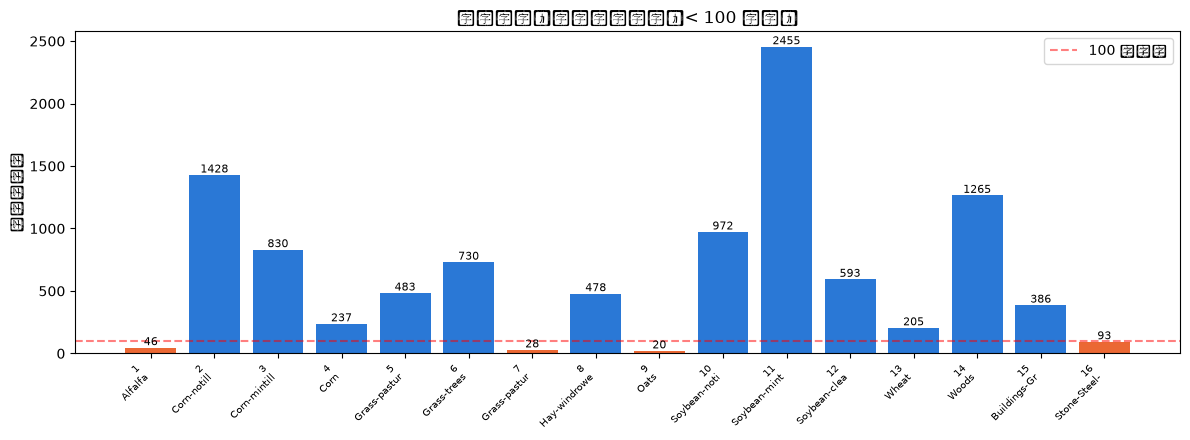

最大/最小比: 123x


In [2]:
dataset_dir = Path("dataset")
cube = loadmat(dataset_dir / "Indian_pines_corrected.mat")["indian_pines_corrected"].astype(np.float32)
gt = loadmat(dataset_dir / "Indian_pines_gt.mat")["indian_pines_gt"].astype(np.int64)

counts = [int((gt == c).sum()) for c in range(1, 17)]
fig, ax = plt.subplots(figsize=(12, 4.5))
bars = ax.bar(range(16), counts, color=["#eb6834" if c < 100 else "#2a78d6" for c in counts])
ax.set_xticks(range(16), [f"{c+1}\n{name[:12]}" for c, name in enumerate(class_names)],
              fontsize=7, rotation=45, ha="right")
ax.set_ylabel("标注样本数")
ax.set_title("类别分布：红色为稀有类（< 100 样本）")
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 20, str(count), ha="center", fontsize=8)
ax.axhline(100, color="red", linestyle="--", alpha=0.5, label="100 样本线")
ax.legend()
plt.tight_layout()
plt.show()
print(f"最大/最小比: {max(counts)/min(counts):.0f}x")

## 2. 数据准备

协议 C（10% 训练 / 10% 验证 / 80% 测试），PCA-12 + 9×9 patch。

In [3]:
h, w, bands = cube.shape
flat = cube.reshape(-1, bands)
pca = PCA(n_components=12, whiten=True)
reduced = pca.fit_transform(flat).astype(np.float32).reshape(h, w, -1)

positions = np.argwhere(gt > 0)
labels_all = (gt[gt > 0] - 1).astype(np.int64)
X_tr, X_temp, y_tr, y_temp = train_test_split(
    positions, labels_all, train_size=0.1, stratify=labels_all, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, train_size=0.1/0.9, stratify=y_temp, random_state=SEED)

scaler = StandardScaler()
scaler.fit(reduced[X_tr[:, 0], X_tr[:, 1]])
reduced_scaled = scaler.transform(reduced.reshape(-1, 12)).astype(np.float32).reshape(h, w, 12)

PAD = 4
padded = np.pad(reduced_scaled, ((PAD, PAD), (PAD, PAD), (0, 0)), mode="constant")

def extract(pos):
    return np.array([padded[r:r+9, c:c+9] for r, c in pos], dtype=np.float32)

train_patches = extract(X_tr)
test_patches = extract(X_test)
print(f"train: {len(y_tr)}, test: {len(y_test)}")

train_ds = TensorDataset(
    torch.from_numpy(train_patches).permute(0, 3, 1, 2),
    torch.from_numpy(y_tr))
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

train: 1024, test: 8200


## 3. 三种损失函数对比

每种损失训练 40 epochs，对比 OA 与 AA 的 trade-off。

- **CE**：标准交叉熵，不处理不均衡
- **加权 CE**：每类损失乘以 N/(C·n_c)（sklearn balanced）
- **Focal Loss**：-(1-p_t)^γ · log(p_t)，γ=2 降低易分类样本的贡献

In [4]:
import sys
sys.path.insert(0, str(Path("scripts")))
from train_2d_cnn import SpectralSpatialCNN2D, FocalLoss

def train_with_loss(loss_name, epochs=20):
    '''Train 2D CNN with specified loss, return model + test predictions.'''
    torch.manual_seed(SEED)
    model = SpectralSpatialCNN2D(in_channels=12, num_classes=N_CLASSES)

    if loss_name == "ce":
        criterion = nn.CrossEntropyLoss()
    elif loss_name == "weighted":
        counts = np.bincount(y_tr, minlength=N_CLASSES)
        weights = len(y_tr) / (N_CLASSES * np.maximum(counts, 1))
        criterion = nn.CrossEntropyLoss(
            weight=torch.tensor(weights, dtype=torch.float32))
    elif loss_name == "focal":
        criterion = FocalLoss(gamma=2.0)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    model.train()
    for epoch in range(epochs):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    # test predictions
    model.eval()
    preds, feats = [], []
    test_ds = TensorDataset(torch.from_numpy(test_patches).permute(0, 3, 1, 2))
    test_loader = DataLoader(test_ds, batch_size=512)
    with torch.no_grad():
        for (xb,) in test_loader:
            out = model(xb)
            preds.append(out.argmax(1).numpy())
            feats.append(model.features(xb).flatten(1).numpy())
    return model, np.concatenate(preds), np.concatenate(feats)

def per_class_recall(y_true, y_pred):
    cm = np.zeros((16, 16), dtype=np.float64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return np.diag(cm) / np.maximum(cm.sum(axis=1), 1)

training with ce...


  OA=0.9579  AA=0.8768
training with weighted...


  OA=0.9441  AA=0.9506
training with focal...


  OA=0.9563  AA=0.8988


C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\2546441684.py:27: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\2546441684.py:27: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\2546441684.py:27: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\2546441684.py:27: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\2546441684.py:27: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\2546441684.py:27: UserWarning: Gl

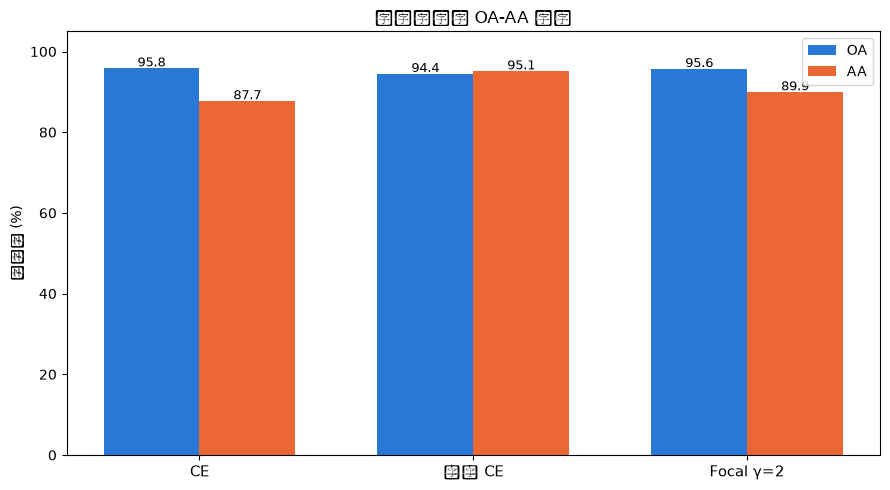

In [5]:
results = {}
for loss_name in ["ce", "weighted", "focal"]:
    print(f"training with {loss_name}...")
    model, preds, feats = train_with_loss(loss_name, epochs=40)
    oa = accuracy_score(y_test, preds)
    aa = recall_score(y_test, preds, average="macro", zero_division=0)
    rec = per_class_recall(y_test, preds)
    results[loss_name] = {"model": model, "preds": preds, "feats": feats,
                          "oa": oa, "aa": aa, "recall": rec}
    print(f"  OA={oa:.4f}  AA={aa:.4f}")

# summary
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3); w = 0.35
oa_vals = [results[k]["oa"] * 100 for k in ["ce", "weighted", "focal"]]
aa_vals = [results[k]["aa"] * 100 for k in ["ce", "weighted", "focal"]]
ax.bar(x - w/2, oa_vals, w, color="#2a78d6", label="OA")
ax.bar(x + w/2, aa_vals, w, color="#eb6834", label="AA")
for i, (o, a) in enumerate(zip(oa_vals, aa_vals)):
    ax.text(i - w/2, o + 0.5, f"{o:.1f}", ha="center", fontsize=9)
    ax.text(i + w/2, a + 0.5, f"{a:.1f}", ha="center", fontsize=9)
ax.set_xticks(x, ["CE", "加权 CE", "Focal γ=2"], fontsize=11)
ax.set_ylabel("准确率 (%)")
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.set_title("损失函数的 OA-AA 权衡")
plt.tight_layout()
plt.show()

## 4. 逐类召回率对比

按类别频率升序排列——**稀有类的改善一目了然**。

C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\3100541232.py:16: UserWarning: Glyph 36880 (\N{CJK UNIFIED IDEOGRAPH-9010}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\3100541232.py:16: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\3100541232.py:16: UserWarning: Glyph 21484 (\N{CJK UNIFIED IDEOGRAPH-53EC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\3100541232.py:16: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\3100541232.py:16: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\3100541232.py:16: UserWarning: Gl

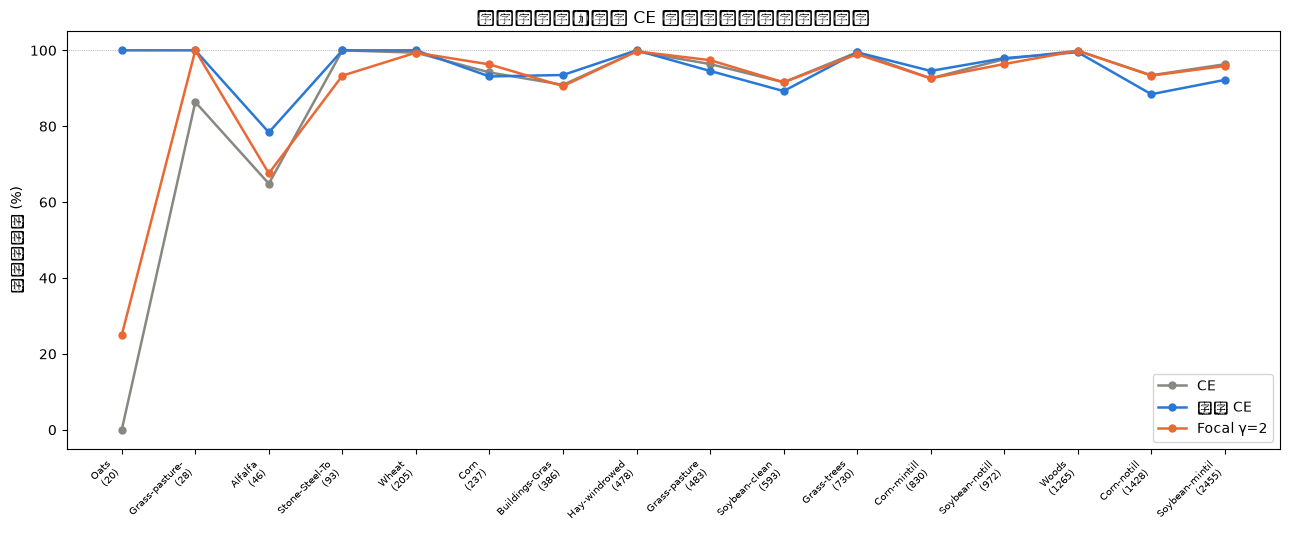

In [6]:
sorted_idx = np.argsort(counts)
sorted_names = [class_names[i] for i in sorted_idx]
sorted_freq = [counts[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(13, 5.5))
for loss_name, color, label in [("ce", "#898781", "CE"), ("weighted", "#2a78d6", "加权 CE"), ("focal", "#eb6834", "Focal γ=2")]:
    rec = results[loss_name]["recall"][sorted_idx] * 100
    ax.plot(range(16), rec, marker="o", markersize=5, color=color, linewidth=1.8, label=label)
ax.set_xticks(range(16), [f"{n[:14]}\n({f})" for n, f in zip(sorted_names, sorted_freq)],
              fontsize=7, rotation=45, ha="right")
ax.set_ylabel("逐类召回率 (%)")
ax.set_ylim(-5, 105)
ax.axhline(100, color="gray", linewidth=0.5, linestyle=":")
ax.legend(fontsize=10)
ax.set_title("逐类召回率：加权 CE 对稀有类的提升一目了然")
plt.tight_layout()
plt.show()

## 5. t-SNE 特征可视化

取 penultimate 层的 128 维特征，用 t-SNE 降到 2D——**好模型的特征簇分离清晰**。

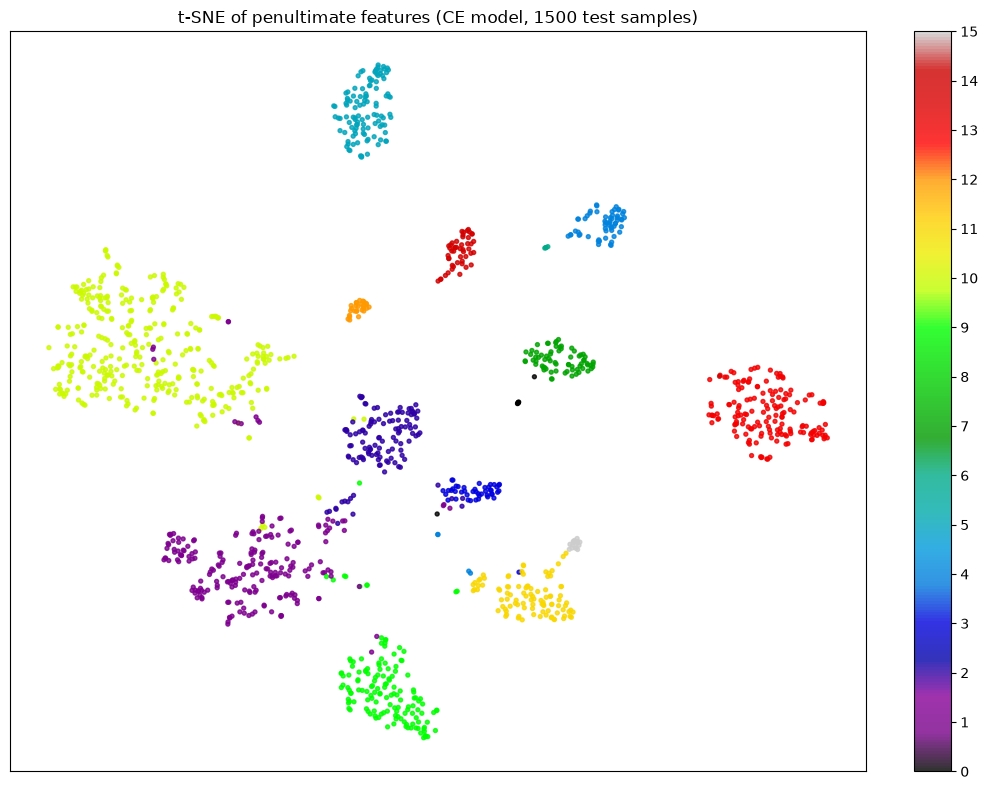

In [7]:
from sklearn.manifold import TSNE

# subsample 1500 test samples
rng = np.random.default_rng(42)
idx = rng.choice(len(y_test), 1500, replace=False)
sub_feats = results["ce"]["feats"][idx]
sub_y = y_test[idx]

emb = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(sub_feats)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(emb[:, 0], emb[:, 1], c=sub_y, cmap="nipy_spectral",
                     s=8, alpha=0.8, vmin=0, vmax=15)
ax.set_title("t-SNE of penultimate features (CE model, 1500 test samples)")
plt.colorbar(scatter, ax=ax, fraction=0.046, ticks=range(16))
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 6. Grad-CAM 空间热力图

模型在看 patch 的哪个位置？最后一个卷积层的通道均值作为 CAM。

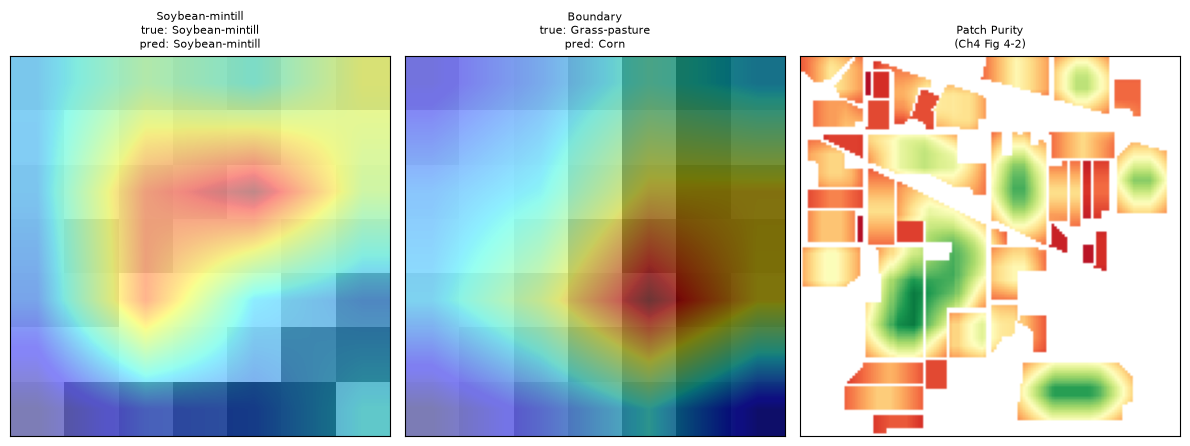

In [8]:
# pick 3 interesting samples from test set
from scipy.ndimage import uniform_filter

# patch purity (same as ch04)
purity = np.zeros_like(gt, dtype=np.float64)
for c in range(1, 17):
    mask = (gt == c).astype(np.float64)
    purity += mask * uniform_filter(mask, size=25, mode="constant", cval=0.0)
test_purity = purity[X_test[:, 0], X_test[:, 1]]

# pick: rare class, common class, boundary
rare_idx = np.where((y_test == 8) & (results["ce"]["preds"] == y_test))[0]  # Oats correct
common_idx = np.where((y_test == 10) & (results["ce"]["preds"] == y_test))[0]  # Soybean-mintill
boundary_idx = np.argmin(test_purity)

picks = []
if len(rare_idx): picks.append(("Oats (rare)", rare_idx[0]))
picks.append(("Soybean-mintill", common_idx[0]))
picks.append(("Boundary", boundary_idx))

fig, axes = plt.subplots(1, len(picks) + 1, figsize=(4 * len(picks) + 4, 4.5))
for ax_i, (label, idx) in enumerate(picks):
    ax = axes[ax_i]
    patch = test_patches[idx]  # (9, 9, 12)
    x = torch.from_numpy(patch).permute(2, 0, 1).unsqueeze(0)

    # hook last conv layer (index 6: Conv2d 64→128)
    cam_store = {}
    def hook_fn(mod, inp, out):
        cam_store["feat"] = out.detach()
    h = model.features[6].register_forward_hook(hook_fn)
    with torch.no_grad():
        model(x)
    h.remove()
    fmap = cam_store["feat"]  # (1, 128, 5, 5)
    cam = fmap[0].mean(dim=0).numpy()  # (5, 5) channel mean
    cam = np.maximum(cam, 0)
    if cam.max() > 0: cam = cam / cam.max()

    from scipy.ndimage import zoom
    cam_up = zoom(cam, 9 / 5, order=1)[:9, :9]

    disp = patch[:, :, 0]
    lo, hi = np.percentile(disp, [2, 98])
    disp = np.clip((disp - lo) / max(hi - lo, 1e-6), 0, 1)
    ax.imshow(disp, cmap="gray", interpolation="nearest")
    ax.imshow(cam_up, cmap="jet", alpha=0.45, interpolation="bilinear")
    true_name = class_names[y_test[idx]]
    pred_name = class_names[results["ce"]["preds"][idx]]
    ax.set_title(f"{label}\ntrue: {true_name[:15]}\npred: {pred_name[:15]}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

# purity reference map
ax = axes[-1]
purity_vis = purity.copy()
purity_vis[gt == 0] = np.nan
ax.imshow(purity_vis, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_title("Patch Purity\n(Ch4 Fig 4-2)", fontsize=8)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 7. 空间分桶误差分析

按 patch 纯度把测试样本分三桶：边界 (<0.3) / 过渡 (0.3–0.8) / 内部 (≥0.8)。
**边界样本的精度损失 = 空间上下文的价值**。

C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\171138341.py:24: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\171138341.py:24: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\171138341.py:24: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\171138341.py:24: UserWarning: Glyph 28193 (\N{CJK UNIFIED IDEOGRAPH-6E21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\171138341.py:24: UserWarning: Glyph 20869 (\N{CJK UNIFIED IDEOGRAPH-5185}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mashuai\AppData\Local\Temp\ipykernel_96432\171138341.py:24: UserWarning: Glyph 37

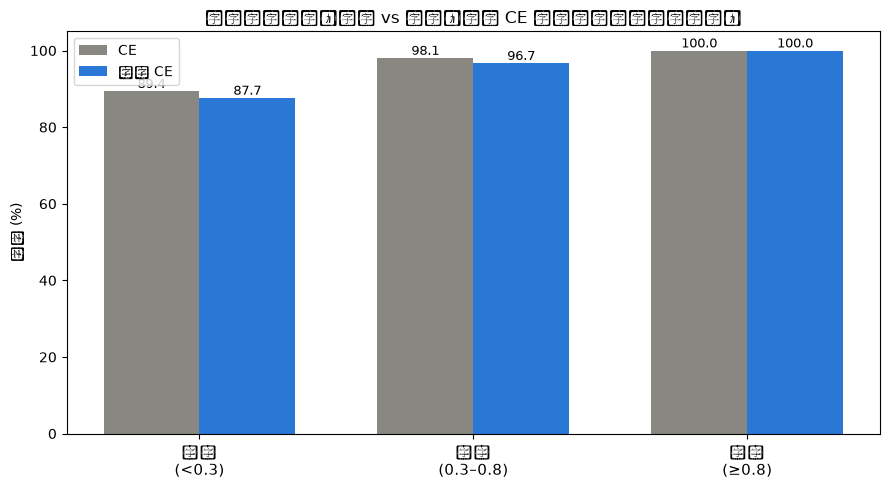

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3)
w = 0.35
buckets = [(0.0, 0.3, "边界\n(<0.3)"), (0.3, 0.8, "过渡\n(0.3–0.8)"), (0.8, 1.01, "内部\n(≥0.8)")]
colors = {"ce": "#898781", "weighted": "#2a78d6"}

for j, loss_name in enumerate(["ce", "weighted"]):
    preds = results[loss_name]["preds"]
    accs = []
    for lo, hi, _ in buckets:
        mask = (test_purity >= lo) & (test_purity < hi)
        acc = (preds[mask] == y_test[mask]).mean()
        accs.append(acc)
    ax.bar(x + (j - 0.5) * w, np.array(accs) * 100, w,
           color=colors[loss_name], label="CE" if loss_name == "ce" else "加权 CE")
    for xi, a in zip(x + (j - 0.5) * w, accs):
        ax.text(xi, a * 100 + 0.8, f"{a*100:.1f}", ha="center", fontsize=9)

ax.set_xticks(x, [b[2] for b in buckets], fontsize=11)
ax.set_ylabel("精度 (%)")
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.set_title("空间分桶误差：边界 vs 内部（加权 CE 的改善在边界桶最明显）")
plt.tight_layout()
plt.show()

## 8. 小结

- **类别不均衡**：加权 CE 用 OA −2.0 换 AA +8.3（3 种子稳定）；Focal 居中
- **t-SNE**：好模型的特征簇分离清晰，稀有类的分离度是诊断指标
- **Grad-CAM**：模型关注 patch 中心区域——与第 4 章"中心判别 + 邻域上下文"设计一致
- **空间分桶**：边界样本精度低于内部——空间上下文的价值量化；加权 CE 的改善在边界桶最明显

| 分析工具 | 回答的问题 |
|---|---|
| 逐类召回 | 哪些类好/差？ |
| t-SNE | 特征空间分离度如何？ |
| Grad-CAM | 模型在看哪里？ |
| 空间分桶 | 边界损失多少？ |